# Dataset description
## Minors workers by school attendance

**Source**: DANE

**Dataset**: [GEIH](https://www.dane.gov.co/index.php/estadisticas-por-tema/mercado-laboral/trabajo-infantil)

# Code
## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from highlight_text import fig_text

## Load data

In [2]:
path = "./data/asistencia_escolar.csv"

df = pd.read_csv(path, encoding="utf-8")

## Clean data

In [3]:
total_work = df[
    (df["Perspectiva"].eq("Total nacional")) &
    (df["Grupo"].str.contains("trabaja"))
]

groups = total_work.groupby(["Fecha", "Concepto"])["Valor"].sum().reset_index()

df_pivot = groups.pivot_table(
    index="Fecha",
    columns="Concepto",
    values="Valor",
    aggfunc="first"
)

shares = df_pivot[["Asiste", "No asiste"]].div(
    df_pivot["Población de 5 a 17 años que trabaja"],
    axis=0
) * 100

def return_total_values(df: pd.DataFrame) -> list:
    values = []
    for column in df.columns:
        buffer = df.loc[:, column]
        values.append(buffer)

    return values

total_values = return_total_values(df_pivot)

attends = total_values[0]
no_attends = total_values[1]

total_shares = return_total_values(shares)
no_attends_shares = total_shares[1]

categories = attends.index

## Plot

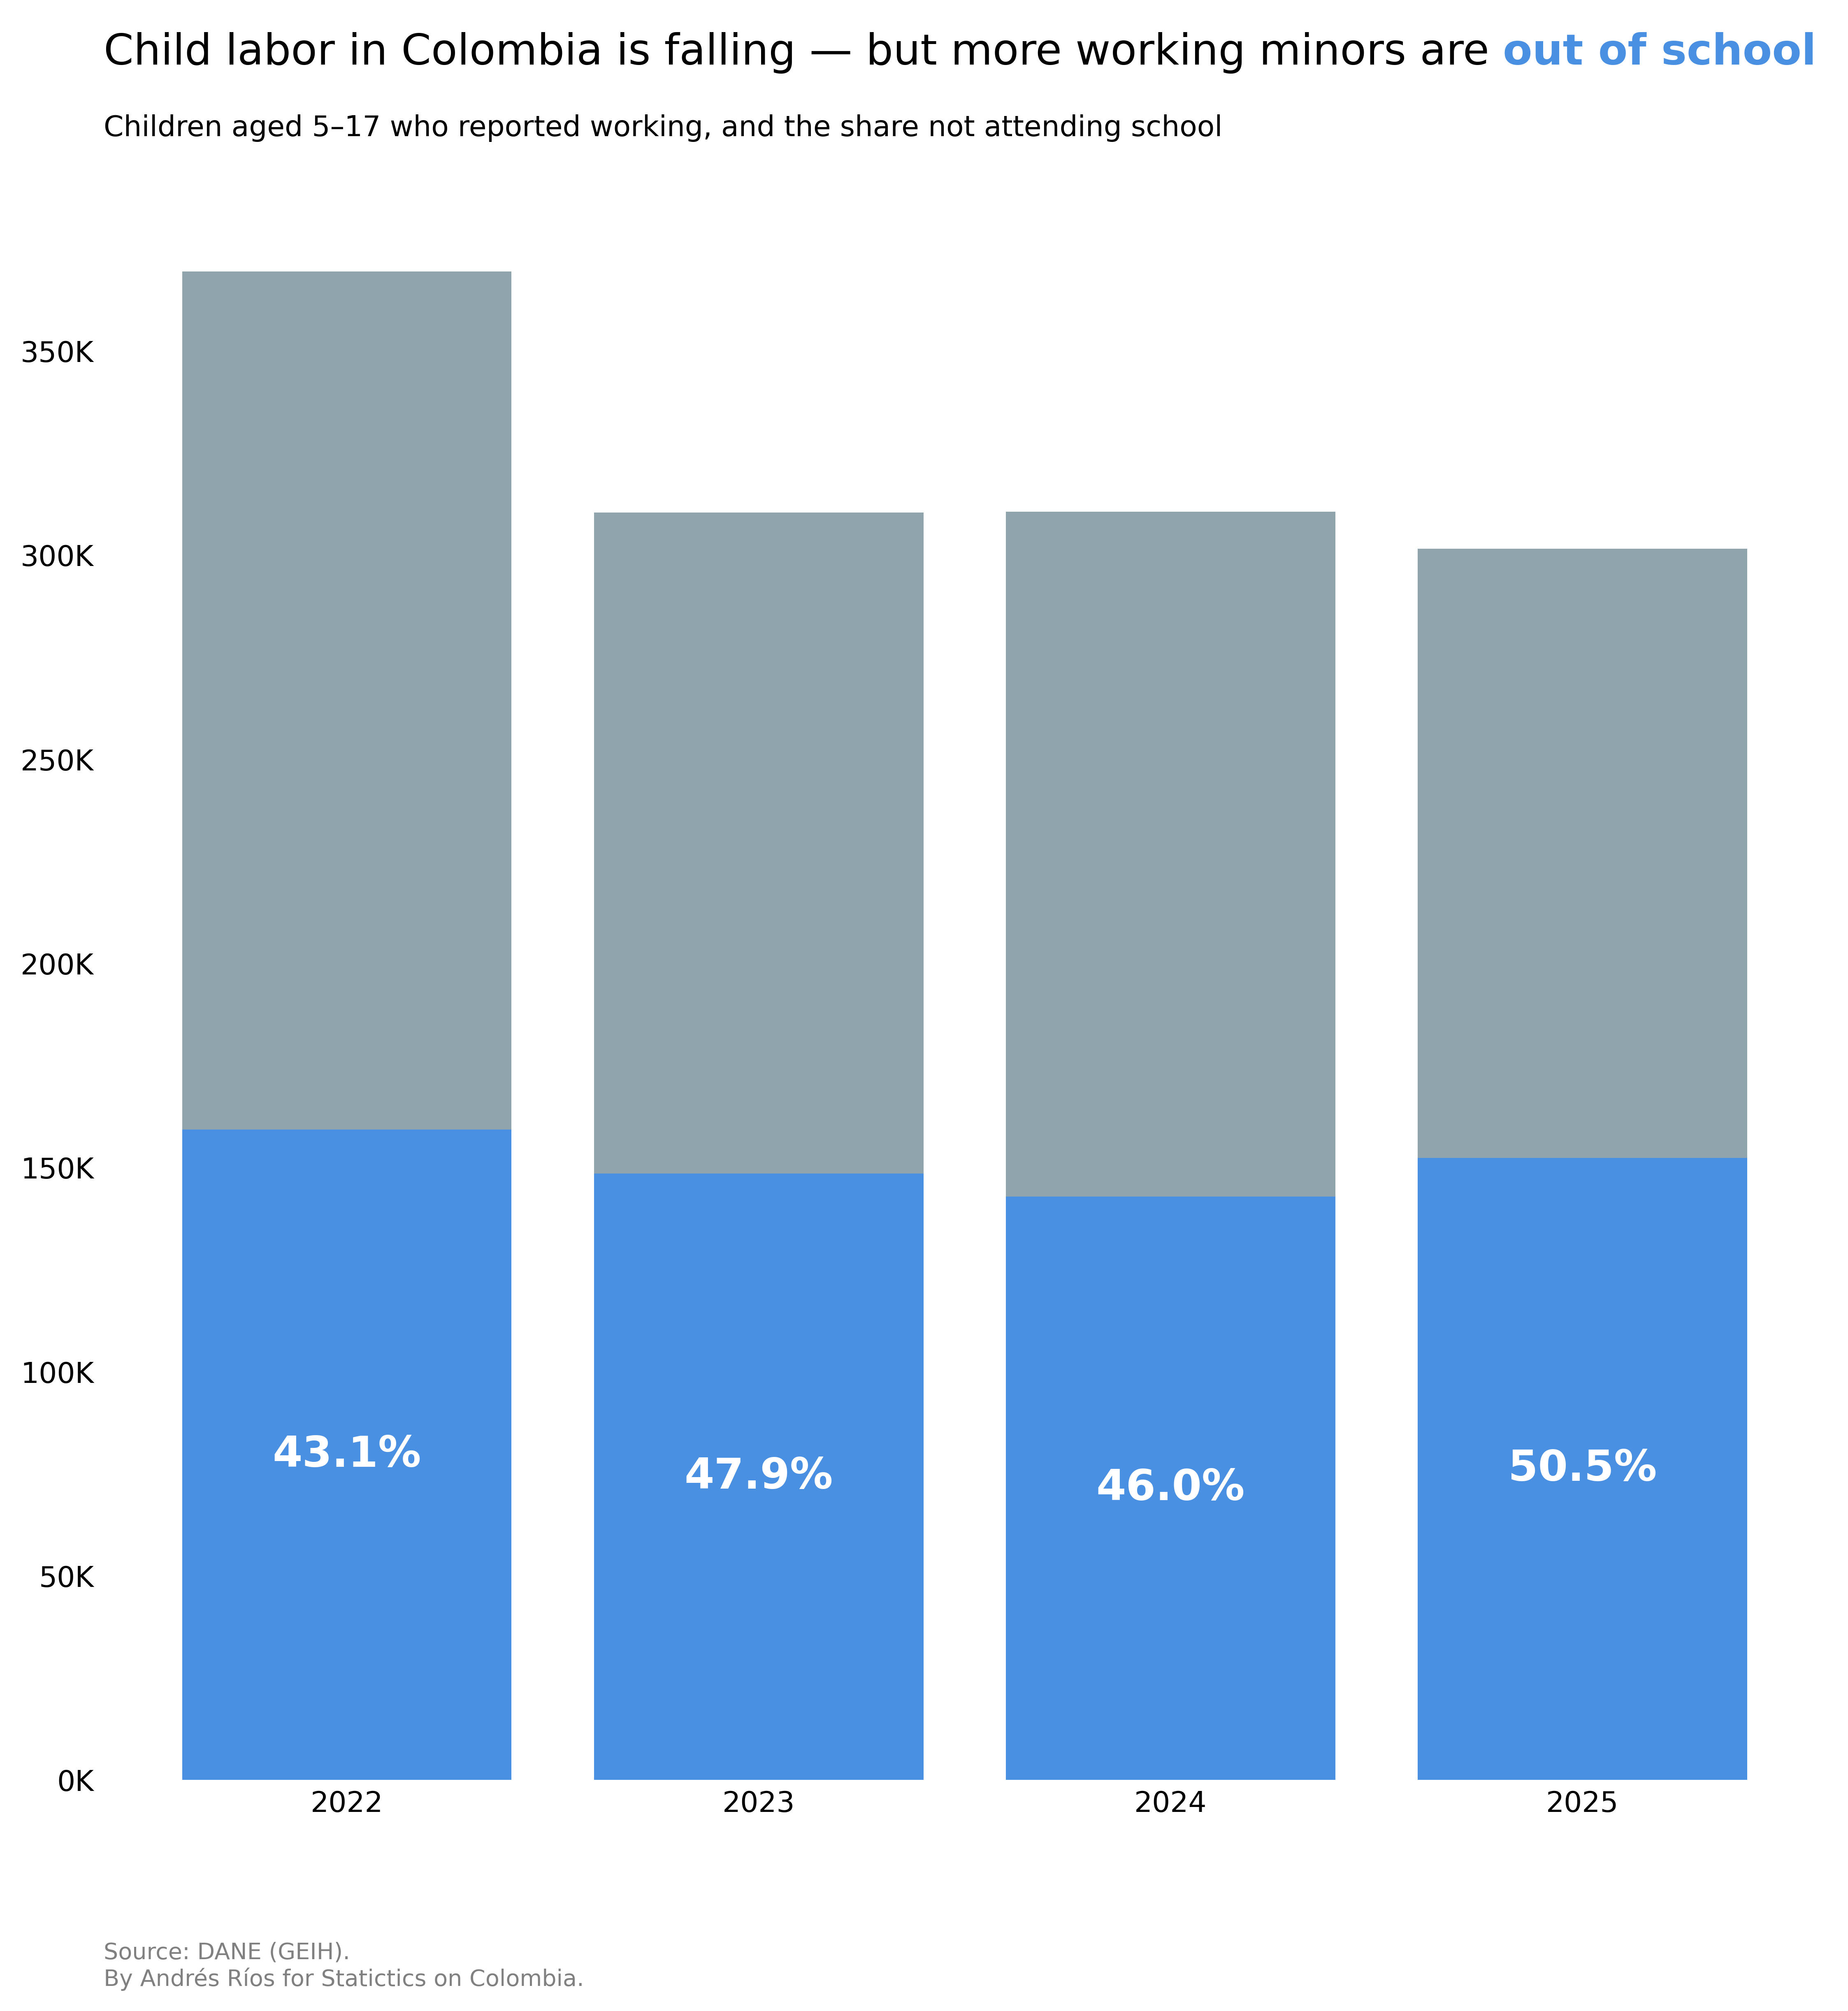

In [4]:
plt.figure(figsize=(10.8, 10), dpi=500)

plt.bar(categories, no_attends.values, color="#4a90e2")
plt.bar(categories, attends.values, bottom=no_attends.values, color="#90A4AE")

plt.xticks(categories)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}K'))

for cat, w, pct in zip(categories, no_attends.values, no_attends_shares.values):
    plt.text(cat, w / 2, f"{pct:.1f}%", ha="center", va="center",
             color="white", fontweight="bold", fontsize=15)


for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

fig_text(
    0.125, 0.96,
    s="Child labor in Colombia is falling — but more working minors are <out of school>",
    highlight_textprops=[{"color": "#4a90e2", "weight": "bold"}],
    fontsize=15,
)

fig_text(
    0.125, 0.92,
    s="Children aged 5–17 who reported working, and the share not attending school",
    fontsize=10,
)

fig = plt.gcf()
fig.text(
    0.125, 0.01, 
    "Source: DANE (GEIH).\n"
    "By Andrés Ríos for Statictics on Colombia.", 
    fontsize=8, color="gray")

plt.show()